# Phase A — TMDB API ile Dengeli Veri Toplama

Resmî TMDB API ile **dengeli + kombinasyon-farkında** film/poster çeker (`src/data/tmdb_api.py`); HTML scraping'in ban sorununu çözer.

**İki faz:** (1) tür bazlı aday havuzu, (2) eksiklik-güdümlü greedy seçim (baskın türler "yolcu" olarak en sona, overshoot azaltılır).

**Çıktı:** `DATA_ROOT/labels_v2.csv` + `DATA_ROOT/posters/{tmdb_id}.jpg`

## 0) Kurulum

In [1]:
import os, sys
from pathlib import Path

# --- Yerel ---
CODE_ROOT = Path('../')
DATA_ROOT = Path('../')

# --- Colab (yukaridaki ikisini yorumlayip bunlari ac) ---
# !pip -q install requests pandas matplotlib
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')
# from google.colab import userdata
# os.environ['TMDB_API_KEY'] = userdata.get('TMDB_API_KEY')   # Secrets'a ekledikten sonra

# Yerelde proje kokundeki .env otomatik okunur (TMDB_API_KEY / TMDB_BEARER).
sys.path.insert(0, str(CODE_ROOT.resolve()))
from src.data.tmdb_api import collect_balanced, download_posters, save_labels, SCARCITY_ORDER

has_key = bool(os.environ.get('TMDB_API_KEY') or os.environ.get('TMDB_BEARER') or (CODE_ROOT / '.env').exists())
assert has_key, 'TMDB anahtari yok: Colab Secrets ekle veya .env doldur'
print('Kurulum OK | DATA_ROOT =', DATA_ROOT.resolve())

Kurulum OK | DATA_ROOT = C:\Users\Kerem\Desktop\MakinÖğrenmesi\film-genre-project


## 1) (Opsiyonel) Smoke test — API + denge mantigini 1 dk'da dogrula

In [2]:
# Kucuk, postersiz cekim — sadece dogrulama
df_smoke = collect_balanced(per_genre=50, min_votes=30)
print()
print('Smoke test satir:', len(df_smoke))
df_smoke.head()

== 1/2 aday havuzu kuruluyor ==
  havuz [History         ]   4 sayfa -> +   80 yeni, havuz toplam=    80
  havuz [Mystery         ]   4 sayfa -> +   79 yeni, havuz toplam=   159
  havuz [Animation       ]   4 sayfa -> +   78 yeni, havuz toplam=   237
  havuz [Fantasy         ]   4 sayfa -> +   51 yeni, havuz toplam=   288
  havuz [Science Fiction ]   4 sayfa -> +   65 yeni, havuz toplam=   353
  havuz [Family          ]   4 sayfa -> +    6 yeni, havuz toplam=   359
  havuz [Horror          ]   4 sayfa -> +   47 yeni, havuz toplam=   406
  havuz [Adventure       ]   4 sayfa -> +    5 yeni, havuz toplam=   411
  havuz [Documentary     ]   4 sayfa -> +   78 yeni, havuz toplam=   489
  havuz [Crime           ]   4 sayfa -> +   61 yeni, havuz toplam=   550
  havuz [Romance         ]   4 sayfa -> +   61 yeni, havuz toplam=   611
  havuz [Action          ]   4 sayfa -> +   10 yeni, havuz toplam=   621
  havuz [Thriller        ]   4 sayfa -> +   11 yeni, havuz toplam=   632
  havuz [Comedy    

,tmdb_id,title,genres,poster_path
0,985939,Fall,[Thriller],/spCAxD99U1A6jsiePFoqdEcY0dG.jpg
1,348,Alien,"[Horror, Science Fiction]",/vfrQk5IPloGg1v9Rzbh2Eg3VGyM.jpg
2,259872,Skin. Like. Sun.,"[Romance, Documentary]",/uCkANtG6ezb7hjRKVudY3PUcbvn.jpg
3,77,Memento,"[Mystery, Thriller]",/fKTPH2WvH8nHTXeBYBVhawtRqtR.jpg
4,853,Enemy at the Gates,[History],/cHRAbVdsCWFaQrswRsBP7Bn255W.jpg


## 2) Tam çekim

Her tür ~2500 hedef (fine-tune için yeterli; daha fazla kombinasyon kapsaması istersen `PER_GENRE`'yi artır — eğitim maliyeti de artar). Rare türler (History vb.) havuzda yetersiz kalırsa `MIN_VOTES`'u düşür veya `POOL_FACTOR`'u artır.

In [4]:
PER_GENRE   = 3000   # tur basina hedef
MIN_VOTES   = 10     # az oylu/kalitesiz filmleri eler; rare turler eksikse 10-20'ye dusur
POOL_FACTOR = 1.5    # rare turler hedefe ulasmiyorsa 2.0-3.0 dene

df = collect_balanced(per_genre=PER_GENRE, min_votes=MIN_VOTES, pool_factor=POOL_FACTOR)
save_labels(df, DATA_ROOT / 'labels_v2.csv')
print('Toplam film:', len(df))

== 1/2 aday havuzu kuruluyor ==
  havuz [History         ] 225 sayfa -> + 3845 yeni, havuz toplam=  3845
  havuz [Mystery         ] 225 sayfa -> + 4447 yeni, havuz toplam=  8292
  havuz [Animation       ] 225 sayfa -> + 4226 yeni, havuz toplam= 12518
  havuz [Fantasy         ] 225 sayfa -> + 2962 yeni, havuz toplam= 15480
  havuz [Science Fiction ] 225 sayfa -> + 3029 yeni, havuz toplam= 18509
  havuz [Family          ] 225 sayfa -> + 1817 yeni, havuz toplam= 20326
  havuz [Horror          ] 225 sayfa -> + 2540 yeni, havuz toplam= 22866
  havuz [Adventure       ] 225 sayfa -> + 1383 yeni, havuz toplam= 24249
  havuz [Documentary     ] 225 sayfa -> + 4026 yeni, havuz toplam= 28275
  havuz [Crime           ] 225 sayfa -> + 3131 yeni, havuz toplam= 31406
  havuz [Romance         ] 225 sayfa -> + 3256 yeni, havuz toplam= 34662
  havuz [Action          ] 225 sayfa -> + 1008 yeni, havuz toplam= 35670
  havuz [Thriller        ] 225 sayfa -> +  524 yeni, havuz toplam= 36194
  havuz [Comedy    

## 3) Poster indirme

In [5]:
ok = download_posters(df, DATA_ROOT / 'posters', size='w500', workers=16)
print(ok, '/', len(df), 'poster indirildi ->', DATA_ROOT / 'posters')

  poster 500/23640 indirildi (başarılı: 500)
  poster 1000/23640 indirildi (başarılı: 1000)
  poster 1500/23640 indirildi (başarılı: 1500)
  poster 2000/23640 indirildi (başarılı: 2000)
  poster 2500/23640 indirildi (başarılı: 2500)
  poster 3000/23640 indirildi (başarılı: 3000)
  poster 3500/23640 indirildi (başarılı: 3500)
  poster 4000/23640 indirildi (başarılı: 4000)
  poster 4500/23640 indirildi (başarılı: 4500)
  poster 5000/23640 indirildi (başarılı: 5000)
  poster 5500/23640 indirildi (başarılı: 5500)
  poster 6000/23640 indirildi (başarılı: 6000)
  poster 6500/23640 indirildi (başarılı: 6500)
  poster 7000/23640 indirildi (başarılı: 7000)
  poster 7500/23640 indirildi (başarılı: 7500)
  poster 8000/23640 indirildi (başarılı: 8000)
  poster 8500/23640 indirildi (başarılı: 8500)
  poster 9000/23640 indirildi (başarılı: 9000)
  poster 9500/23640 indirildi (başarılı: 9500)
  poster 10000/23640 indirildi (başarılı: 10000)
  poster 10500/23640 indirildi (başarılı: 10500)
  poster 11

## 4) Çekim öncesi/sonrası dağılım (rapor / vize figürü)

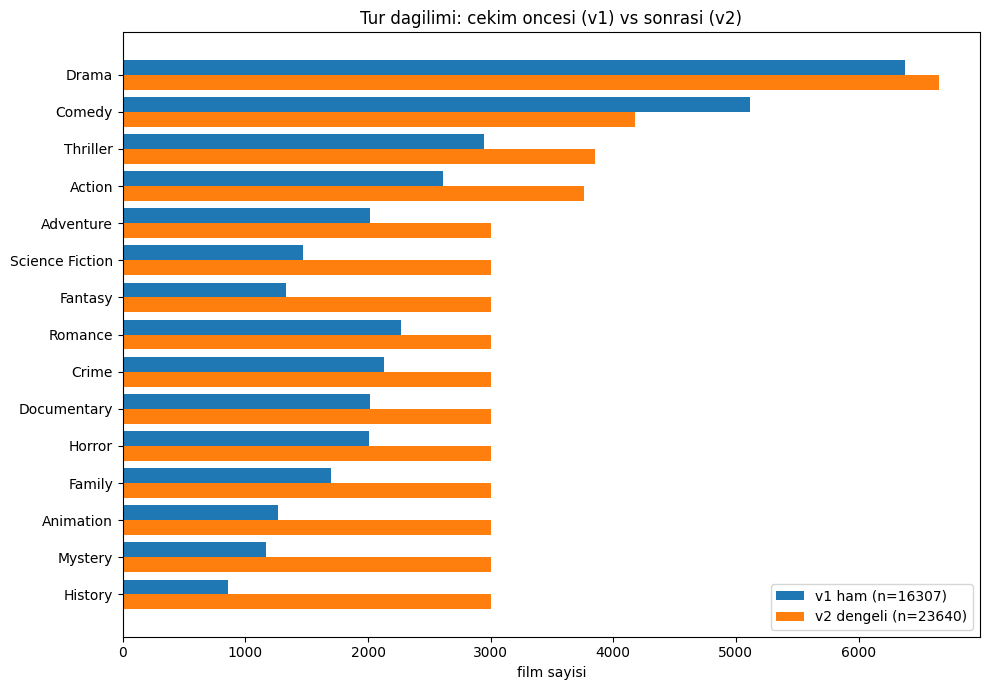

v2 max/min orani: 2.22x


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def genre_counts(csv_path):
    d = pd.read_csv(csv_path, dtype={'tmdb_id': str})
    d['genres'] = d['genres'].apply(lambda x: x.split('|') if isinstance(x, str) else [])
    c = Counter(g for gs in d['genres'] for g in gs if g in SCARCITY_ORDER)
    return c, len(d)

before, n_before = genre_counts(DATA_ROOT / 'labels.csv')     # v1 (dengesiz)
after,  n_after  = genre_counts(DATA_ROOT / 'labels_v2.csv')  # v2 (dengeli)

order = sorted(SCARCITY_ORDER, key=lambda g: after.get(g, 0))
y = np.arange(len(order)); h = 0.4
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(y + h/2, [before.get(g, 0) for g in order], height=h, label='v1 ham (n=%d)' % n_before)
ax.barh(y - h/2, [after.get(g, 0)  for g in order], height=h, label='v2 dengeli (n=%d)' % n_after)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlabel('film sayisi'); ax.legend()
ax.set_title('Tur dagilimi: cekim oncesi (v1) vs sonrasi (v2)')
plt.tight_layout()
fig.savefig(DATA_ROOT / 'dist_before_after.png', dpi=120)
plt.show()
print('v2 max/min orani: %.2fx' % (max(after.values()) / min(after.values())))